#Preprocessing Dataset Titanic

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load Dataset & EDA Singkat

In [2]:
# Load dataset Titanic
df = sns.load_dataset('titanic')

# Pilih kolom yang digunakan
cols = [
    'pclass',
    'sex',
    'age',
    'sibsp',
    'parch',
    'fare',
    'embarked',
    'survived'
]

df = df[cols].copy()

# Menampilkan 5 data pertama
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [3]:
# Ukuran dataset
print('Shape Dataset:')
print(df.shape)

print('\nMissing Values:')
print(df.isnull().sum())

print('\nTipe Data:')
print(df.dtypes)

print('\nDistribusi Target:')
print(df['survived'].value_counts(normalize=True).round(3))

Shape Dataset:
(891, 8)

Missing Values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Tipe Data:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object

Distribusi Target:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


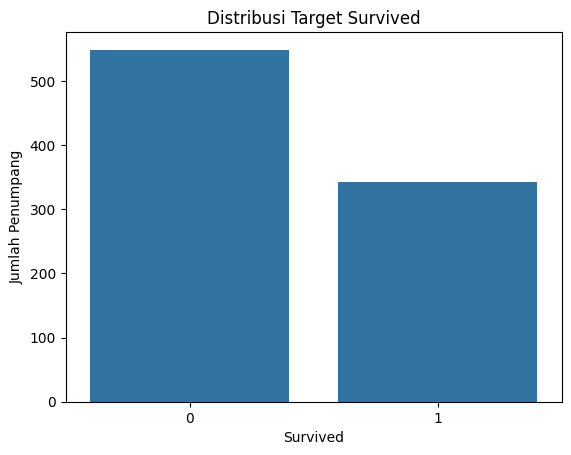

In [4]:
# Visualisasi distribusi target
sns.countplot(x='survived', data=df)

plt.title('Distribusi Target Survived')
plt.xlabel('Survived')
plt.ylabel('Jumlah Penumpang')

plt.show()

Handling Missing Values

In [5]:
# Mengisi missing value pada kolom age dengan median
df['age'] = df['age'].fillna(df['age'].median())

# Mengisi missing value pada kolom embarked dengan modus
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Missing Values Setelah Handling:')
print(df.isnull().sum())

Missing Values Setelah Handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


Encoding Kategorikal

In [6]:
# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['sex', 'embarked'],
    drop_first=True,
    dtype=int
)

print('Kolom Setelah Encoding:')
print(df.columns.tolist())

Kolom Setelah Encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


In [7]:
# Melihat hasil encoding
df.head()

,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,1,0,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,3,26.0,0,0,7.9250,1,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,1


Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur dan target
X = df.drop('survived', axis=1)
y = df['survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')

print('\nProporsi Survived di Train:')
print(y_train.value_counts(normalize=True).round(3))

print('\nProporsi Survived di Test:')
print(y_test.value_counts(normalize=True).round(3))

Train: 712 baris
Test : 179 baris

Proporsi Survived di Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi Survived di Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


Feature Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

# Kolom numerik yang akan di-scale
num_cols = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

# Membuat scaler
scaler = StandardScaler()

# Scaling data train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Scaling data test
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('Mean scaler (dari train):')
print(scaler.mean_.round(2))

print('\nStd scaler (dari train):')
print(scaler.scale_.round(2))

Mean scaler (dari train):
[ 2.31 29.46  0.49  0.39 31.82]

Std scaler (dari train):
[ 0.83 13.03  1.06  0.84 48.03]


In [10]:
# Menampilkan contoh data setelah scaling
print('Contoh X_train setelah scaling:')

print(X_train.head(3).round(3))

Contoh X_train setelah scaling:
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1


In [11]:
print('Data siap dilatih model Machine Learning!')

print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')

print(f'X_test : {X_test.shape}')
print(f'y_test : {y_test.shape}')

Data siap dilatih model Machine Learning!
X_train: (712, 8)
y_train: (712,)
X_test : (179, 8)
y_test : (179,)
